#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### por: Francisco Weitzman

## Introducción
En este trabajo vamos a explorar el comportamiento de distintas funciones, en tiempo y en frecuencia, con estas variables discretas.

#### Item 1)

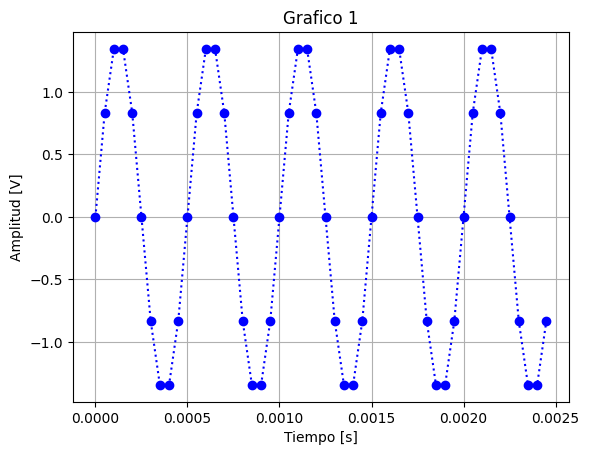

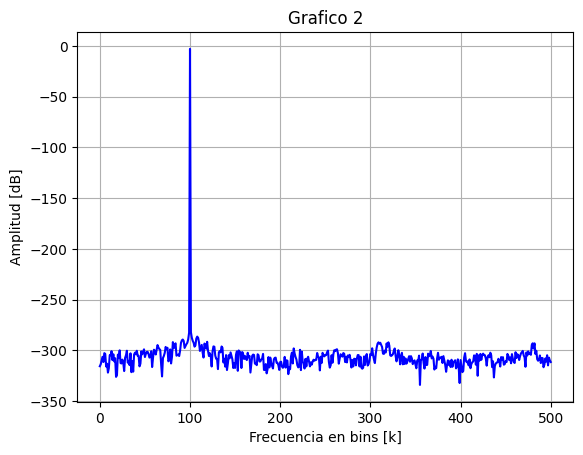

In [143]:
import numpy as np
import matplotlib.pyplot as plt
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+np.pi*ph)
    tt=nn/fs
    return(tt,xx)


#%% Definiciones para el a)

fs = 20000 # Hz. Queremos que haya 10 muestras en un ciclo en una señal de 2kHz => fs=f_señal*10
# Aclaracion de fs:       fs = f*MPC (muestras por ciclo, en este caso 10)
N = 1000 # muestras (me las dan)
vmax=np.sqrt(2) # pot = 1
dc=0 # Valor medio (alrededor del que oscila)

# buscamos la resolucion espectral --> df=20'000/1000 = 20
df=fs/N # Resolucion Espectral

# buscamos el k: f=k*df --> 2000=k*20 --> k=100
k = 100 # frecuencia de bin
kk = np.arange(0,k)
kdf=k*df # es nuestra f deseada = 2000Hz

ph=0
nn=np.arange(0,N)
mu=0 #valor medio
tt, xx= mi_funcion_sen(vmax, dc, kdf, ph, nn, fs)
modulo_tr=np.abs(np.fft.fft(xx)/N)
dB_modulo_tr = 20*np.log10(modulo_tr)

#%% Grafico 1

plt.figure()
plt.plot(tt[:50],xx[:50], ':o', color="blue")
plt.title("Grafico 1", fontdict=None, loc=None, pad=None)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

plt.figure()
plt.title("Grafico 2", fontdict=None, loc=None, pad=None)
plt.plot(dB_modulo_tr[:N//2+1], color="blue")
plt.xlabel("Frecuencia en bins [k]")
plt.ylabel("Amplitud [dB]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()




Si ploteamos algunos ciclos de una sinusoidal de 2KHz con 10 muestras por ciclo y luego ploteamos el espectro de frecuencia hasta la frecuencia de Nyquist, obtenemos los gráficos 1 y 2. Notamos que en k = 100 está concentrada la energía de la onda total. El ruido restante se debe a el redondeo por el numero de mantisa que es, por supuesto, finito, y no con la señal en sí.
Tambien es interesante notar que normalizamos nuestra transformada de fourier con un factor de 1/N, lo que permite que no se amplifique los valores del módulo de cada frecuencia en el espectro.

#### Item 2)

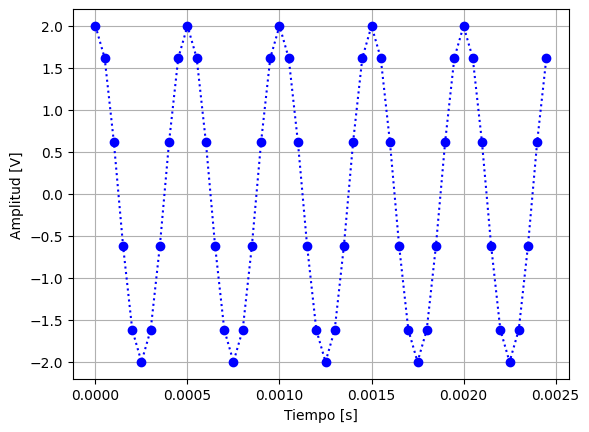

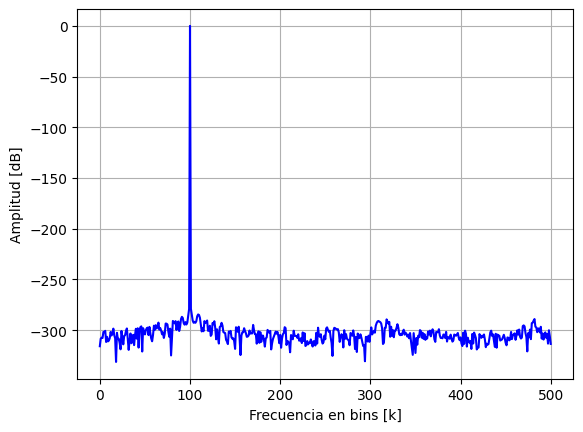

In [144]:
pot = 2
vmax = np.sqrt(2*pot)
ph = 1/2
tt, xx= mi_funcion_sen(vmax, dc, kdf, ph, nn, fs)
#%% Grafico 1

plt.figure()
plt.plot(tt[:50],xx[:50], ':o', color="blue")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

modulo_tr=np.abs(np.fft.fft(xx)/N)
dB_modulo_tr = 20*np.log10(modulo_tr)


plt.figure()
plt.plot(dB_modulo_tr[:N//2+1], color="blue")
plt.xlabel("Frecuencia en bins [k]")
plt.ylabel("Amplitud [dB]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()


Acá lo unico que buscamos fue cambiar la potencia de la señal y desfasarla. La potencia en una sinusoideal se calcula como


$P_{sin} = \frac{V_{max}^2}{2}$

que es la varianza. Ambas coinciden si $μ = 0$ (la media)

#### Item 3)

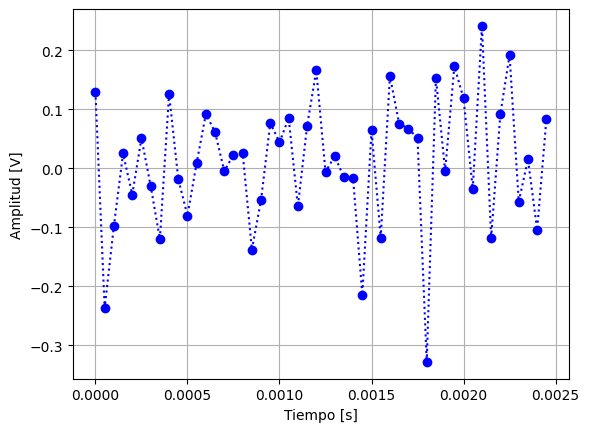

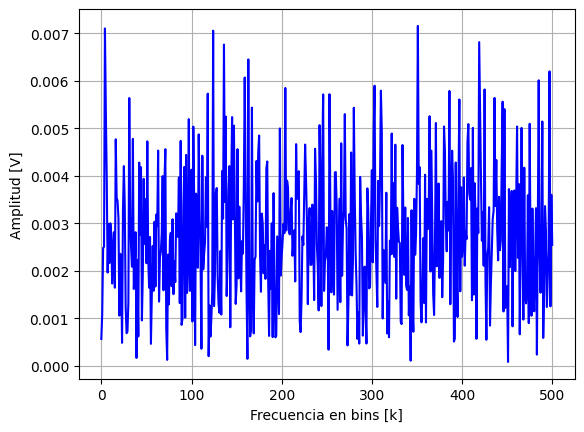

In [145]:
##% item c)
# Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
def ruidoNormal(N,mu,pot_ruido):
  yy = np.random.normal(mu,pot_ruido,N)
  return (yy)
mu = 0 # [V]
pot_ruido = 0.1 # [W]
yy = ruidoNormal(N, mu, pot_ruido)

#%% Grafico 1
plt.figure()
plt.plot(tt[:50],yy[:50], ':o', color="blue")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

modulo_tr=np.abs(np.fft.fft(yy)/N)
dB_modulo_tr = 20*np.log10(modulo_tr)


plt.figure()
plt.plot(modulo_tr[:N//2+1], color="blue")
plt.xlabel("Frecuencia en bins [k]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

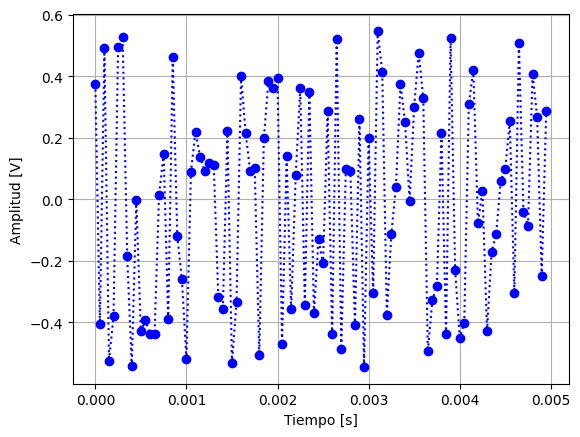

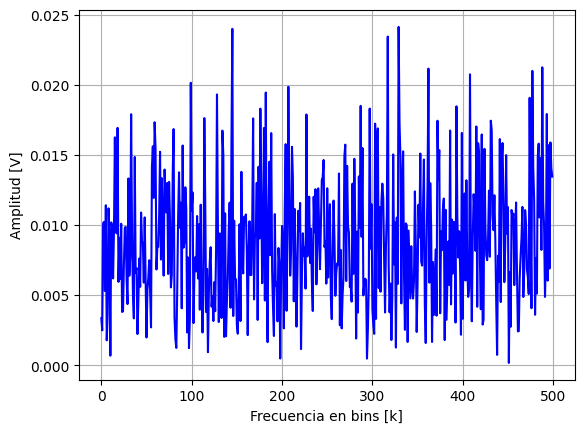

In [146]:
##% item d)
# Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
def ruidoUniforme(N,mu,pot_ruido):
  # Varianza_uniforme = (b-a)^2/12 = b^2/3 = 0.1
  # sqrt(0.1 * 3) = b
  limite = np.sqrt(3*pot_ruido)
  yy = np.random.uniform(-limite,limite,N)
  return (yy)
mu = 0 # [V]
pot_ruido = 0.1 # [W]
yy = ruidoUniforme(N, mu, pot_ruido)

#%% Grafico 1
plt.figure()
plt.plot(tt[:100],yy[:100], ':o', color="blue")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

modulo_tr=np.abs(np.fft.fft(yy)/N)


plt.figure()
plt.plot(modulo_tr[:N//2], color="blue")
plt.xlabel("Frecuencia en bins [k]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

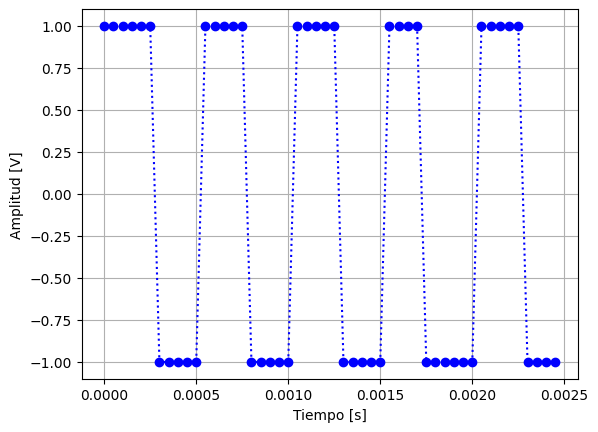

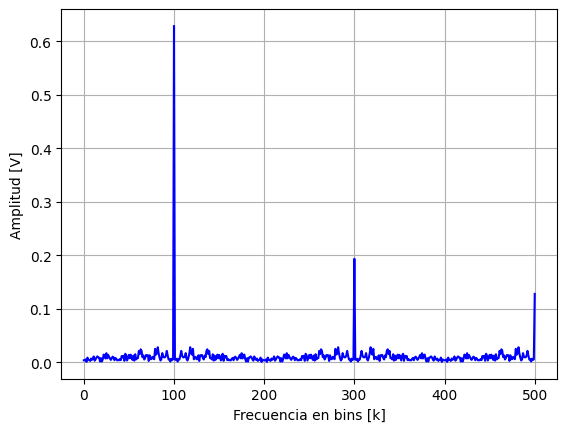

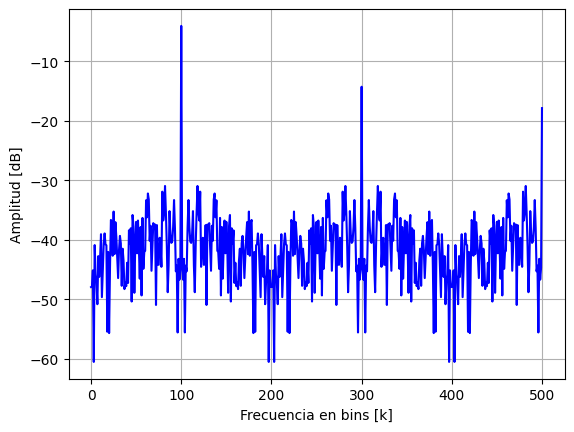

In [147]:
# Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%
from scipy import signal

cuadrada = signal.square(2*np.pi*kdf*nn/fs,0.5)

#%% Grafico 1
plt.figure()
plt.plot(tt[:50],cuadrada[:50], ':o', color="blue")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()

modulo_tr=np.abs(np.fft.fft(cuadrada)/N)
dB_modulo_tr = 20*np.log10(modulo_tr)

plt.figure()
plt.plot(modulo_tr[:N//2+1], color="blue")
plt.xlabel("Frecuencia en bins [k]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()


plt.figure()
plt.plot(dB_modulo_tr[:N//2+1], color="blue")
plt.xlabel("Frecuencia en bins [k]")
plt.ylabel("Amplitud [dB]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.show()
